# MNIST Digit Classifier

First neural network: a simple fully-connected net trained to recognize handwritten digits (0-9).
This is the warm-up for the traffic sign classifier - same pipeline, easier dataset.

**Result: 97.01% test accuracy after 3 epochs.**

In [90]:
# Imports: torchvision for the MNIST dataset, matplotlib for visualization,
# DataLoader for batching, torch/nn for building and training the network
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

## 1. Load and explore the data

In [91]:
# Download the MNIST training set (60,000 handwritten digit images, 28x28 grayscale)
# train=True gives us the official training split
# ToTensor() converts each image to a PyTorch tensor with pixel values scaled to [0, 1]
train_data = datasets.MNIST(root='../data', train=True, download=True, transform=transforms.ToTensor())

In [92]:
# Sanity check: confirm we have all 60,000 training images
print(len(train_data))

60000


torch.Size([1, 28, 28])
5


Text(0.5, 1.0, 'Label: 5')

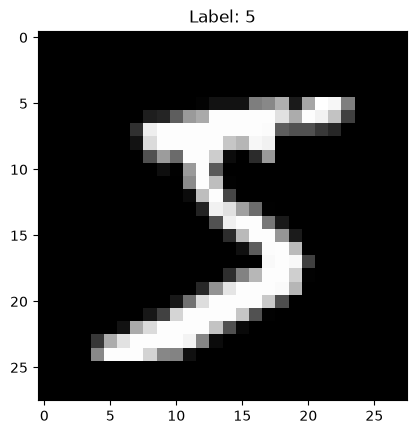

In [93]:
# Look at one sample: each image is shape [1, 28, 28] (1 channel, 28x28 pixels)
# and comes with its true label
image, label = train_data[0]
print(image.shape)
print(label)
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label: {label}')


In [94]:
# Download the test set (10,000 images the model will never see during training)
# train=False gives us the official held-out test split
test_data = datasets.MNIST(root='../data', train=False, download=True, transform=transforms.ToTensor())
print(f"Train: {len(train_data)}, Test: {len(test_data)}")

Train: 60000, Test: 10000


In [95]:
# DataLoaders chunk the datasets into batches of 64 images
# shuffle=True mixes the training data each epoch so the model doesn't learn the order
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# One batch = 64 images of shape [1, 28, 28] and 64 labels
image, label = next(iter(train_loader))
print(image.shape)
print(label.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


## 2. Build the model

In [ ]:
# A simple fully-connected neural network:
#   flatten: 1x28x28 image -> 784 numbers
#   layer1:  784 inputs  -> 128 neurons
#   relu:    negatives become 0 (lets the network learn non-linear patterns)
#   layer2:  128 -> 10 output scores, one per digit (0-9)
# The highest of the 10 scores is the model's prediction
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128,10)

    def forward(self, x):
        # Defines the path data takes through the network
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


In [97]:
# Sanity check: push one batch through the untrained model
# Expect shape [64, 10] -> 64 images, 10 scores each (predictions are still random)
model = SimpleNet()
images, labels = next(iter(train_loader))
outputs = model(images)
print(outputs.shape)

torch.Size([64, 10])


## 3. Train

In [98]:
# Loss function: CrossEntropyLoss measures how wrong the predictions are.
# It heavily penalizes being confidently wrong - the standard choice for classification.
loss_fn = nn.CrossEntropyLoss()

# Optimizer: Adam adjusts the model's weights to reduce the loss.
# lr (learning rate) controls how big each adjustment is.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [99]:
# Training loop: 3 epochs (3 full passes through all 60,000 images)
# Each epoch processes 938 batches of 64 images
for epoch in range(3):
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()               # wipe gradients from the previous batch
        outputs =  model(images)            # forward pass: predict
        loss = loss_fn(outputs, labels)     # measure how wrong we were
        loss.backward()                     # work out which way to adjust each weight
        optimizer.step()                    # apply the adjustments
        total_loss += loss.item()           # track loss for the epoch average
    print(f"Epoch [{epoch+1}/3], Avg Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/3], Avg Loss: 0.3418
Epoch [2/3], Avg Loss: 0.1566
Epoch [3/3], Avg Loss: 0.1099


## 4. Evaluate

In [100]:
# Evaluate on the 10,000 test images the model has never seen
correct = 0
total = 0
with torch.no_grad():                        # no training here, so skip gradient tracking
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) # index of the highest score = predicted digit
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.01%
